# Sensitivity Analysis of ODE Market-Making Model

Global sensitivity analysis (Sobol indices) and forward uncertainty quantification
for the 2-currency (USD, EUR) ODE approximation.

See `notes/sensitivity-analysis/setup.md` for methodology documentation.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from tqdm import tqdm
import time

from src import build_paper_example_params, restrict_currencies, run_multicurrency_mm
from src.model import ModelParams, PairParams, TierParams, BP

## Parameter setup

8 parameters varied over uniform ranges around the paper's nominal values (Table 1, EUR/USD).

In [30]:
PARAM_NAMES = [
    r"$\sigma_{EUR}$", r"$\gamma$", r"$\lambda_{scale}$",
    r"$\alpha_1$", r"$\alpha_2$",
    r"$\beta_1$", r"$\beta_2$", r"$\eta$"
]

PARAM_LABELS = [
    "sigma_EUR", "gamma", "lambda_scale",
    "alpha_1", "alpha_2", "beta_1", "beta_2", "eta"
]

# Nominal values in human-readable units
# sigma: bps, gamma: 1/M$, lambda_scale: multiplier,
# alpha: dimensionless, beta: 1/bps (paper units), eta: bps
NOMINAL = np.array([80.0, 20.0, 1.0, -1.9, -0.3, 11.0, 3.5, 1e-5])

RANGES = np.array([
    [56.0, 104.0],       # sigma_EUR (bps), +-30%
    [10.0, 40.0],        # gamma, +-50%
    [0.5, 1.5],          # lambda_scale, +-50%
    [-2.5, -1.3],        # alpha_1, +-30%
    [-0.9, 0.3],         # alpha_2, +-100%
    [7.7, 14.3],         # beta_1 (1/bps), +-30%
    [2.45, 4.55],        # beta_2 (1/bps), +-30%
    [0.5e-5, 2.0e-5],    # eta (bps), +-50%
])

QOI_NAMES = [
    r"$\delta^*(y{=}0)$ [bps]",
    r"$\delta^*(y{=}10) - \delta^*(y{=}0)$ [bps]",
    r"$\xi^*(y{=}10)$ [M$/day]",
]

N_PARAMS = len(PARAM_NAMES)
N_QOIS = len(QOI_NAMES)

## Model evaluation

Map the 8-dimensional parameter vector to 3 scalar quantities of interest
via the Riccati ODE solver.

In [31]:
# Cache base parameters to avoid rebuilding every call
_base = restrict_currencies(build_paper_example_params(), ["USD", "EUR"])
_base_pp = _base.pairs[("EUR", "USD")]


def build_modified_params(params):
    """Build 2-currency (USD, EUR) ModelParams from parameter vector.

    params[0]: sigma_EUR in bps
    params[1]: gamma (risk aversion)
    params[2]: lambda_scale (multiplier on all arrival rates)
    params[3]: alpha_1 (logistic shift, aggressive tier)
    params[4]: alpha_2 (logistic shift, passive tier)
    params[5]: beta_1 (logistic slope, aggressive, in 1/bps paper units)
    params[6]: beta_2 (logistic slope, passive, in 1/bps paper units)
    params[7]: eta (execution cost quadratic, in bps)
    """
    sigma_eur, gamma, lam_scale, a1, a2, b1, b2, eta = params

    tiers = [
        TierParams(alpha=a1, beta=b1 * 1e4),
        TierParams(alpha=a2, beta=b2 * 1e4),
    ]

    pp = PairParams(
        pair=("EUR", "USD"),
        sizes_musd=_base_pp.sizes_musd,
        lambdas_per_day=_base_pp.lambdas_per_day * lam_scale,
        tiers=tiers,
        psi=_base_pp.psi,
        eta=eta * BP,
    )

    return ModelParams(
        currencies=["USD", "EUR"],
        ref_ccy="USD",
        sigma={"USD": 0.0, "EUR": sigma_eur * BP},
        corr={},
        k=_base.k,
        mu={"USD": 0.0, "EUR": 0.0},
        gamma=gamma,
        kappa=np.zeros((2, 2)),
        T_days=_base.T_days,
        pairs={("EUR", "USD"): pp},
    )


def evaluate_qois(params):
    """Solve ODE and return 3 QoIs.

    Returns: [delta*(y=0) in bps, inventory skew in bps, hedge rate in M$/day]
    """
    mp = build_modified_params(params)
    res = run_multicurrency_mm(mp, n_steps=500)

    y_flat = np.zeros(2)
    y_long = np.array([0.0, 10.0])  # 10 M$ long EUR

    # QoI 1: neutral markup (tier 1, z=1 M$) in bps
    delta_flat = res.markup(0, "EUR", "USD", 1.0, y_flat)

    # QoI 2: inventory skew in bps
    delta_long = res.markup(0, "EUR", "USD", 1.0, y_long)
    skew = delta_long - delta_flat

    # QoI 3: hedge rate at y=10 (M$/day)
    xi = res.hedge_rate("EUR", "USD", y_long)

    return np.array([delta_flat / BP, skew / BP, xi])

In [32]:
# Sanity check: evaluate at nominal and verify n_steps=500 vs 2000
qoi_500 = evaluate_qois(NOMINAL)

mp_nom = build_modified_params(NOMINAL)
res_2000 = run_multicurrency_mm(mp_nom, n_steps=2000)
y_flat = np.zeros(2)
y_long = np.array([0.0, 10.0])
d_flat = res_2000.markup(0, "EUR", "USD", 1.0, y_flat)
d_long = res_2000.markup(0, "EUR", "USD", 1.0, y_long)
xi_2000 = res_2000.hedge_rate("EUR", "USD", y_long)
qoi_2000 = np.array([d_flat / BP, (d_long - d_flat) / BP, xi_2000])

print("QoIs at nominal parameter values:")
print(f"{'QoI':>40s}  {'n=500':>10s}  {'n=2000':>10s}  {'rel err':>10s}")
for name, v500, v2000 in zip(QOI_NAMES, qoi_500, qoi_2000):
    err = abs(v500 - v2000) / (abs(v2000) + 1e-30)
    print(f"{name:>40s}  {v500:10.4f}  {v2000:10.4f}  {err:10.2e}")

# Time a single evaluation
t0 = time.time()
for _ in range(100):
    evaluate_qois(NOMINAL)
t_per = (time.time() - t0) / 100
print(f"\nTime per evaluation: {t_per*1000:.1f} ms")
print(f"Estimated time for N=10000 Sobol: {t_per * 10000 * (N_PARAMS + 2) / 60:.1f} min")

QoIs at nominal parameter values:
                                     QoI       n=500      n=2000     rel err
                 $\delta^*(y{=}0)$ [bps]      0.1822      0.1822    0.00e+00
$\delta^*(y{=}10) - \delta^*(y{=}0)$ [bps]      0.1261      0.1261    1.10e-15
                $\xi^*(y{=}10)$ [M$/day]  -1878.6063  -1878.6063    6.29e-15

Time per evaluation: 7.0 ms
Estimated time for N=10000 Sobol: 11.6 min


## Sobol indices

Global sensitivity analysis using Saltelli's Monte Carlo estimator.

- First-order $S_i$: fraction of output variance due to parameter $i$ alone (Saltelli 2010)
- Total-effect $S_{Ti}$: includes all interactions involving parameter $i$ (Jansen 1999)

Total model evaluations: $N \times (k + 2)$ where $k = 8$ parameters.

In [33]:
def saltelli_sample(N, ranges, seed=42):
    """Generate two independent uniform sample matrices A, B scaled to parameter ranges."""
    rng = np.random.default_rng(seed)
    k = ranges.shape[0]
    lo, hi = ranges[:, 0], ranges[:, 1]
    A = lo + rng.random((N, k)) * (hi - lo)
    B = lo + rng.random((N, k)) * (hi - lo)
    return A, B


def evaluate_saltelli_samples(model_func, A, B):
    """Evaluate model at all Saltelli sample points.

    Returns f_A (N, n_qoi), f_B (N, n_qoi), f_C (k, N, n_qoi).
    """
    N, k = A.shape
    total = N * (k + 2)

    # Stack all parameter sets: A, B, C_0, ..., C_{k-1}
    all_params = np.empty((total, k))
    all_params[:N] = A
    all_params[N:2*N] = B
    for i in range(k):
        C_i = A.copy()
        C_i[:, i] = B[:, i]
        all_params[(2 + i) * N:(3 + i) * N] = C_i

    # Evaluate all samples
    n_qoi = len(model_func(A[0]))
    results = np.empty((total, n_qoi))

    for j in tqdm(range(total), desc="Saltelli evaluations", mininterval=2.0):
        results[j] = model_func(all_params[j])

    # Unpack
    f_A = results[:N]
    f_B = results[N:2*N]
    f_C = np.empty((k, N, n_qoi))
    for i in range(k):
        f_C[i] = results[(2 + i) * N:(3 + i) * N]

    return f_A, f_B, f_C


def compute_sobol_indices(f_A, f_B, f_C):
    """Compute first-order and total-effect Sobol indices.

    First-order (Saltelli 2010):  S_i  = mean(f_B * (f_Ci - f_A)) / Var(Y)
    Total-effect (Jansen 1999):  S_Ti = mean((f_A - f_Ci)^2) / (2 * Var(Y))
    """
    N, n_qoi = f_A.shape
    k = f_C.shape[0]

    f_all = np.concatenate([f_A, f_B], axis=0)
    var_Y = np.var(f_all, axis=0)

    S = np.empty((k, n_qoi))
    S_T = np.empty((k, n_qoi))

    for i in range(k):
        S[i] = np.mean(f_B * (f_C[i] - f_A), axis=0) / var_Y
        S_T[i] = np.mean((f_A - f_C[i])**2, axis=0) / (2.0 * var_Y)

    return S, S_T

In [34]:
N_SOBOL = 10_000

print(f"Sobol analysis: N={N_SOBOL}, k={N_PARAMS}, total evals={N_SOBOL*(N_PARAMS+2)}")
A, B = saltelli_sample(N_SOBOL, RANGES, seed=42)
f_A, f_B, f_C = evaluate_saltelli_samples(evaluate_qois, A, B)

Sobol analysis: N=10000, k=8, total evals=100000


Saltelli evaluations: 100%|██████████| 100000/100000 [12:22<00:00, 134.75it/s]


In [35]:
S, S_T = compute_sobol_indices(f_A, f_B, f_C)

print("First-order Sobol indices (S_i):")
print(f"{'':>15s}  {'QoI 1':>8s}  {'QoI 2':>8s}  {'QoI 3':>8s}")
for i in range(N_PARAMS):
    vals = "  ".join(f"{S[i, q]:8.3f}" for q in range(N_QOIS))
    print(f"{PARAM_LABELS[i]:>15s}  {vals}")

print(f"\nTotal-effect Sobol indices (S_Ti):")
print(f"{'':>15s}  {'QoI 1':>8s}  {'QoI 2':>8s}  {'QoI 3':>8s}")
for i in range(N_PARAMS):
    vals = "  ".join(f"{S_T[i, q]:8.3f}" for q in range(N_QOIS))
    print(f"{PARAM_LABELS[i]:>15s}  {vals}")

print(f"\nSum of S_i:  {S.sum(axis=0)}  (should be close to 1 if interactions are small)")
print(f"Sum of S_Ti: {S_T.sum(axis=0)}  (>1 indicates interactions)")

First-order Sobol indices (S_i):
                    QoI 1     QoI 2     QoI 3
      sigma_EUR     0.002     0.325     0.215
          gamma     0.000     0.338     0.220
   lambda_scale     0.002     0.291     0.188
        alpha_1     0.173     0.005     0.006
        alpha_2     0.000     0.001     0.000
         beta_1     0.784     0.012     0.030
         beta_2     0.000     0.011     0.006
            eta     0.000     0.000     0.157

Total-effect Sobol indices (S_Ti):
                    QoI 1     QoI 2     QoI 3
      sigma_EUR     0.001     0.347     0.296
          gamma     0.001     0.376     0.317
   lambda_scale     0.001     0.299     0.257
        alpha_1     0.180     0.006     0.009
        alpha_2     0.000     0.001     0.001
         beta_1     0.818     0.012     0.044
         beta_2     0.000     0.007     0.006
            eta     0.000     0.000     0.282

Sum of S_i:  [0.96042586 0.98354733 0.8235107 ]  (should be close to 1 if interactions are small)
Sum 

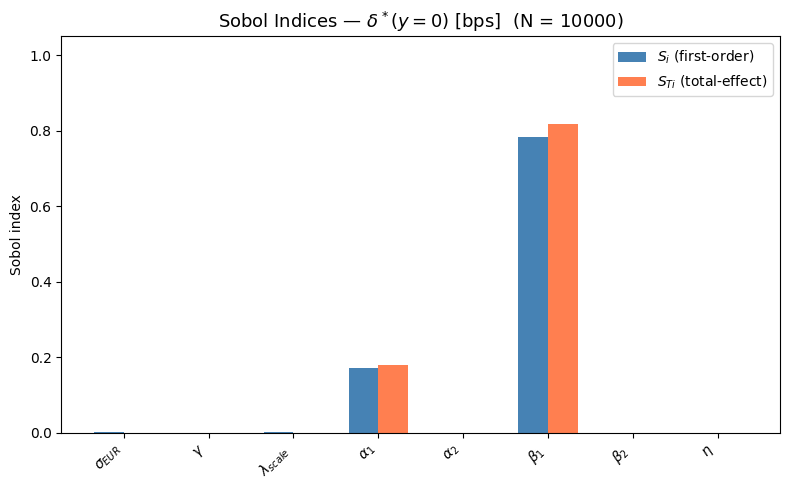

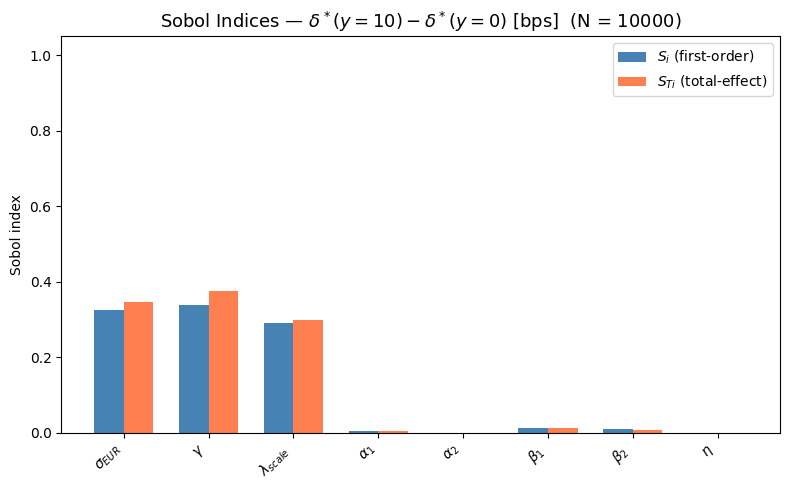

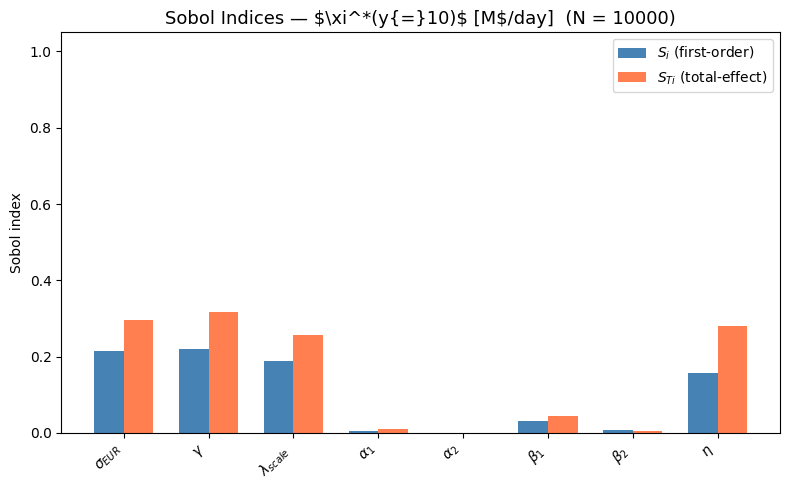

In [36]:
x = np.arange(N_PARAMS)
width = 0.35

for q in range(N_QOIS):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, S[:, q], width, label=r'$S_i$ (first-order)', color='steelblue')
    ax.bar(x + width/2, S_T[:, q], width, label=r'$S_{Ti}$ (total-effect)', color='coral')
    ax.set_ylabel('Sobol index')
    ax.set_title(f'Sobol Indices — {QOI_NAMES[q]}  (N = {N_SOBOL})', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(PARAM_NAMES, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

## Forward Uncertainty Quantification

Sample parameters from uniform priors, propagate through the ODE model,
and estimate the distribution of each quantity of interest via kernel density estimation.

In [37]:
# Reuse the Sobol A and B evaluations as forward UQ samples (2N = 20,000 points)
fwd_qois = np.concatenate([f_A, f_B], axis=0)
N_FWD = fwd_qois.shape[0]
print(f"Forward UQ using {N_FWD} samples (reused from Sobol computation)")

nominal_qois = evaluate_qois(NOMINAL)

print(f"\n{'QoI':>45s}  {'mean':>8s}  {'std':>8s}  {'5%':>8s}  {'95%':>8s}  {'nominal':>8s}")
for q in range(N_QOIS):
    data = fwd_qois[:, q]
    print(f"{QOI_NAMES[q]:>45s}  {data.mean():8.3f}  {data.std():8.3f}  "
          f"{np.percentile(data, 5):8.3f}  {np.percentile(data, 95):8.3f}  "
          f"{nominal_qois[q]:8.3f}")

Forward UQ using 20000 samples (reused from Sobol computation)

                                          QoI      mean       std        5%       95%   nominal
                      $\delta^*(y{=}0)$ [bps]     0.189     0.037     0.138     0.257     0.182
   $\delta^*(y{=}10) - \delta^*(y{=}0)$ [bps]     0.152     0.058     0.075     0.262     0.126
                     $\xi^*(y{=}10)$ [M$/day]  -3206.644  3414.464  -9812.464     0.000  -1878.606


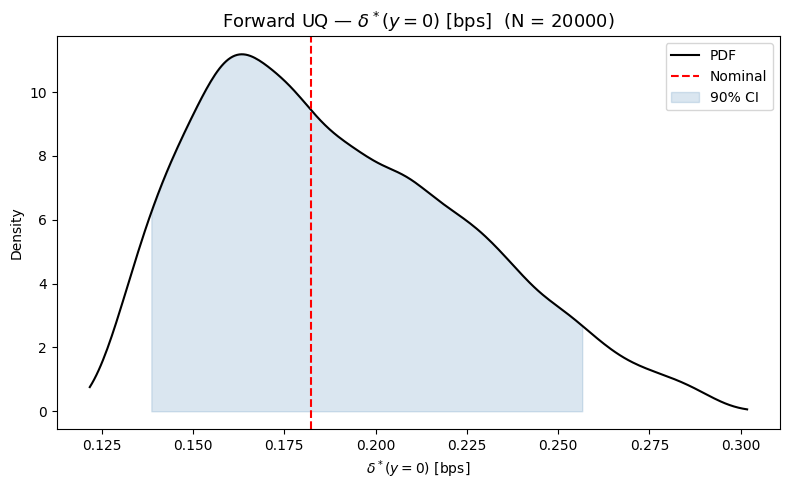

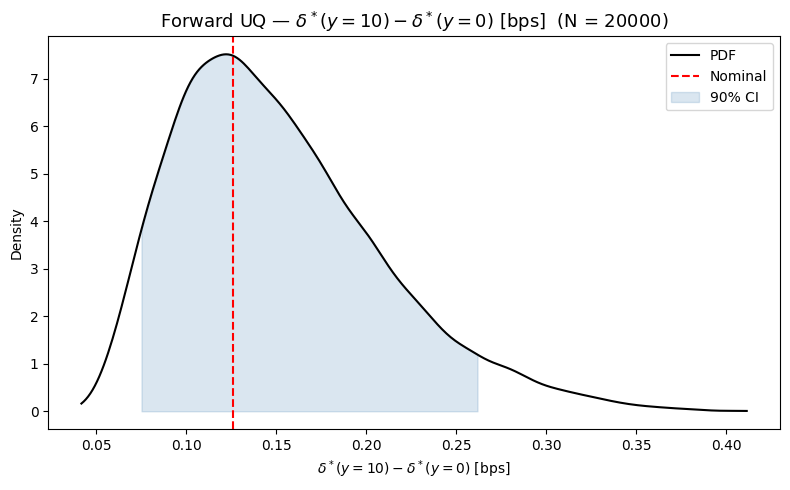

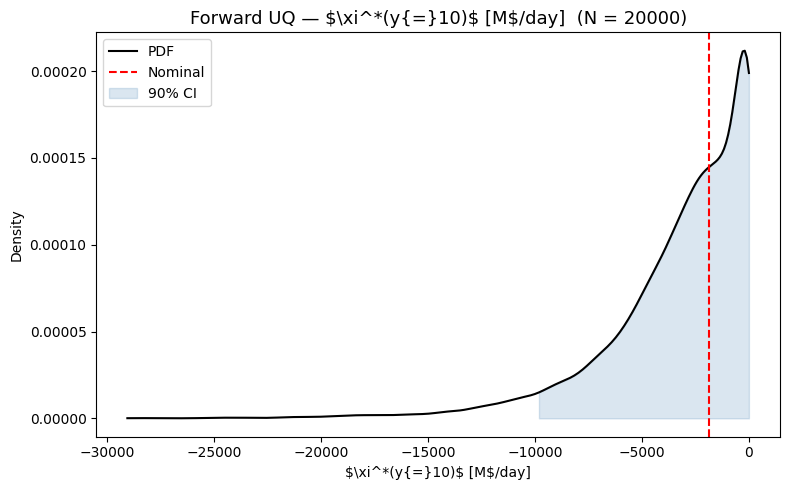

In [38]:
for q in range(N_QOIS):
    fig, ax = plt.subplots(figsize=(8, 5))
    data = fwd_qois[:, q]

    # KDE with Silverman bandwidth
    kde = gaussian_kde(data, bw_method='silverman')
    x_grid = np.linspace(data.min(), data.max(), 300)
    ax.plot(x_grid, kde(x_grid), 'k-', linewidth=1.5, label='PDF')
    ax.axvline(nominal_qois[q], color='r', linestyle='--', linewidth=1.5, label='Nominal')

    # Shade 90% CI
    p5, p95 = np.percentile(data, [5, 95])
    mask = (x_grid >= p5) & (x_grid <= p95)
    ax.fill_between(x_grid[mask], kde(x_grid[mask]), alpha=0.2, color='steelblue', label='90% CI')

    ax.set_xlabel(QOI_NAMES[q])
    ax.set_ylabel('Density')
    ax.set_title(f'Forward UQ — {QOI_NAMES[q]}  (N = {N_FWD})', fontsize=13)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

## PDE Validation

Solve the full HJB PDE at nominal and extreme parameter values to verify
that the ODE-based sensitivity conclusions hold. For each of the 4 important
parameters (sigma, gamma, lambda, eta), we solve the PDE at the low and high
end of the range and compare the QoIs against the ODE.

9 PDE solves total (1 nominal + 2 per parameter x 4 parameters).

In [ ]:
from src.pde import solve_hjb_implicit
from src.hamiltonian import optimal_delta_logistic
from src.policy import Hprime_execution_cost

# PDE grid: [-150, 150] M$, dy=1.0
Y_MAX = 150
DY = 1.0
y_grids_pde = [np.arange(-Y_MAX, Y_MAX + DY, DY) for _ in range(2)]
idx_origin = len(y_grids_pde[0]) // 2
PDE_N_STEPS = 20
PDE_PI_TOL = 1e-4

print(f"PDE grid: [{-Y_MAX}, {Y_MAX}] M$, dy={DY}, points/axis={len(y_grids_pde[0])}")
print(f"PDE time steps: {PDE_N_STEPS}, PI tol: {PDE_PI_TOL}")


def pde_extract_qois(theta_0, y_grids, mp):
    """Extract the 3 QoIs from PDE solution theta(0, y).

    Same QoIs as evaluate_qois but computed from the PDE grid directly:
      QoI 1: delta*(y=0)  — optimal markup at flat inventory
      QoI 2: delta*(y=10) - delta*(y=0)  — inventory skew
      QoI 3: xi*(y=10)  — hedge rate at 10 M$ EUR
    """
    idx0 = len(y_grids[0]) // 2
    dy = y_grids[0][1] - y_grids[0][0]

    key = ("EUR", "USD")
    pp = mp.pairs[key]
    tier = pp.tiers[0]
    z = 1.0
    shift = int(round(z / dy))

    # Quoting: EUR pays (i=1), USD sells (j=0) -> dvec = [-1, +1]
    # Shifted point: [y_USD - z, y_EUR + z]

    # QoI 1: delta*(y=0)
    # p = (theta(y) - theta(y + z*dvec)) / z
    p_flat = (theta_0[idx0, idx0] - theta_0[idx0 - shift, idx0 + shift]) / z
    delta_flat = optimal_delta_logistic(p_flat, tier.alpha, tier.beta)

    # QoI 2: delta*(y=[0,10]) - delta*(y=0)
    y_eur_idx = 10  # 10 M$ EUR = 10 grid points
    p_long = (theta_0[idx0, idx0 + y_eur_idx] -
              theta_0[idx0 - shift, idx0 + y_eur_idx + shift]) / z
    delta_long = optimal_delta_logistic(p_long, tier.alpha, tier.beta)
    skew = delta_long - delta_flat

    # QoI 3: xi*(y=[0,10])
    # Gradient via central differences
    grad_usd = (theta_0[idx0 + 1, idx0 + y_eur_idx] -
                theta_0[idx0 - 1, idx0 + y_eur_idx]) / (2 * dy)
    grad_eur = (theta_0[idx0, idx0 + y_eur_idx + 1] -
                theta_0[idx0, idx0 + y_eur_idx - 1]) / (2 * dy)

    # Hedge EUR buy, USD sell: base = grad_EUR - grad_USD
    base = grad_eur - grad_usd

    # Market impact (small but included for correctness)
    k_eur = mp.k.get("EUR", 0.0)
    k_usd = mp.k.get("USD", 0.0)
    impact = k_eur * 10.0 * (1.0 + grad_eur) - k_usd * 0.0 * (1.0 + grad_usd)

    xi = Hprime_execution_cost(base + impact, pp.psi, pp.eta)

    return np.array([delta_flat / BP, skew / BP, xi])

In [ ]:
# Define parameter configurations: nominal + edges for the 4 important parameters
configs = {}
configs["nominal"] = NOMINAL.copy()

for idx, label, lo, hi in [
    (0, "sigma", RANGES[0, 0], RANGES[0, 1]),
    (1, "gamma", RANGES[1, 0], RANGES[1, 1]),
    (2, "lambda", RANGES[2, 0], RANGES[2, 1]),
    (7, "eta", RANGES[7, 0], RANGES[7, 1]),
]:
    p_lo = NOMINAL.copy(); p_lo[idx] = lo
    p_hi = NOMINAL.copy(); p_hi[idx] = hi
    configs[f"{label}_low"] = p_lo
    configs[f"{label}_high"] = p_hi

# Solve ODE and PDE for each configuration
results_ode = {}
results_pde = {}

for name, params in configs.items():
    print(f"\n{'='*60}")
    print(f"Config: {name}")
    print(f"{'='*60}")

    # ODE (fast)
    results_ode[name] = evaluate_qois(params)

    # PDE (slow)
    mp = build_modified_params(params)
    pde_result = solve_hjb_implicit(
        y_grids_pde, mp, n_steps=PDE_N_STEPS,
        pi_tol=PDE_PI_TOL, pi_max_iter=50,
    )
    results_pde[name] = pde_extract_qois(pde_result['theta_0'], y_grids_pde, mp)

    # Print comparison
    print(f"\n  {'QoI':>10s}  {'ODE':>12s}  {'PDE':>12s}  {'rel diff':>10s}")
    for q in range(N_QOIS):
        ode_val = results_ode[name][q]
        pde_val = results_pde[name][q]
        rd = abs(ode_val - pde_val) / (abs(pde_val) + 1e-30)
        print(f"  {'QoI '+str(q+1):>10s}  {ode_val:12.4f}  {pde_val:12.4f}  {rd:10.2e}")

In [ ]:
# Compare sensitivities: (QoI at edge - QoI at nominal) for ODE vs PDE
param_pairs = [
    ("sigma", "sigma_low", "sigma_high"),
    ("gamma", "gamma_low", "gamma_high"),
    ("lambda", "lambda_low", "lambda_high"),
    ("eta", "eta_low", "eta_high"),
]

qoi_short = [r"$\delta^*(y{=}0)$", "skew", r"$\xi^*$"]

print("Sensitivity comparison: Delta(QoI) = QoI(edge) - QoI(nominal)")
print("=" * 85)

for label, lo_key, hi_key in param_pairs:
    print(f"\n--- {label} ---")
    print(f"  {'QoI':>15s}  {'ODE low':>10s}  {'PDE low':>10s}  {'ODE high':>10s}  {'PDE high':>10s}")
    for q in range(N_QOIS):
        ode_lo = results_ode[lo_key][q] - results_ode["nominal"][q]
        pde_lo = results_pde[lo_key][q] - results_pde["nominal"][q]
        ode_hi = results_ode[hi_key][q] - results_ode["nominal"][q]
        pde_hi = results_pde[hi_key][q] - results_pde["nominal"][q]
        print(f"  {qoi_short[q]:>15s}  {ode_lo:+10.4f}  {pde_lo:+10.4f}  {ode_hi:+10.4f}  {pde_hi:+10.4f}")

In [ ]:
# Visual comparison: ODE vs PDE sensitivities side by side
fig, axes = plt.subplots(1, N_QOIS, figsize=(6 * N_QOIS, 5))

param_labels_short = [r"$\sigma$", r"$\gamma$", r"$\lambda$", r"$\eta$"]
x = np.arange(len(param_pairs))
width = 0.35

for q in range(N_QOIS):
    ax = axes[q]

    # Compute sensitivity magnitude: (high - low) for ODE and PDE
    ode_range = []
    pde_range = []
    for label, lo_key, hi_key in param_pairs:
        ode_range.append(results_ode[hi_key][q] - results_ode[lo_key][q])
        pde_range.append(results_pde[hi_key][q] - results_pde[lo_key][q])

    ax.bar(x - width/2, ode_range, width, label='ODE', color='steelblue')
    ax.bar(x + width/2, pde_range, width, label='PDE', color='coral')
    ax.set_ylabel('QoI(high) - QoI(low)')
    ax.set_title(QOI_NAMES[q], fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(param_labels_short)
    ax.legend(fontsize=10)
    ax.axhline(0, color='k', linewidth=0.5)

plt.suptitle('Sensitivity: ODE vs PDE', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()